# Model V2 — LightGBM (Hourly, Engineered Features)

In [2]:
import pandas as pd
import numpy as np
import lightgbm as lgb
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import matplotlib.pyplot as plt

## 1. Load Data

In [3]:
df = pd.read_csv('../data/convertData/V2_finland_electricity_features.csv')
print(df.shape)
df.head()

(26304, 43)


,datetime,price,temp,wind_speed,hour,day_of_week,day_of_month,month,week_of_year,quarter,...,price_rolling_mean_24h,price_rolling_std_24h,price_rolling_min_24h,price_rolling_max_24h,price_rolling_mean_168h,temp_rolling_mean_24h,HDD,wind_power_proxy,temp_lag_24h,temp_lag_168h
0,2023-01-01 00:00:00,4.84,4.433333,8.516667,0,6,1,1,52,1,...,NaN,NaN,NaN,NaN,NaN,NaN,12.566667,617.744588,NaN,NaN
1,2023-01-01 01:00:00,2.01,4.100000,7.716667,1,6,1,1,52,1,...,NaN,NaN,NaN,NaN,NaN,NaN,12.900000,459.503921,NaN,NaN
2,2023-01-01 02:00:00,1.38,3.800000,8.150000,2,6,1,1,52,1,...,NaN,NaN,NaN,NaN,NaN,NaN,13.200000,541.343375,NaN,NaN
3,2023-01-01 03:00:00,0.09,3.616667,9.333333,3,6,1,1,52,1,...,NaN,NaN,NaN,NaN,NaN,NaN,13.383333,813.037037,NaN,NaN
4,2023-01-01 04:00:00,0.08,2.516667,11.700000,4,6,1,1,52,1,...,NaN,NaN,NaN,NaN,NaN,NaN,14.483333,1601.613000,NaN,NaN


## 2. Train / Validation / Test Split

No shuffle — this is time-series data, future must not leak into training.

- **Test set:** last 20% of all data — completely held out
- **Train set:** first 80% of all data — used for fitting
- **Early stopping monitor:** last 10% of the training portion — passed as `eval_set` to detect overfitting, but still included in training

In [4]:
X = df.drop(columns=['price', 'datetime'])
y = df['price']

n = len(df)
test_size  = int(n * 0.20)
train_end  = n - test_size

X_train = X.iloc[:train_end]
y_train = y.iloc[:train_end]

X_test  = X.iloc[train_end:]
y_test  = y.iloc[train_end:]

# last 10% of training used as early stopping monitor (still part of training)
monitor_start = train_end - int(n * 0.10)
X_monitor = X.iloc[monitor_start:train_end]
y_monitor = y.iloc[monitor_start:train_end]

print(f'Train   : {X_train.shape}')
print(f'Monitor : {X_monitor.shape}')
print(f'Test    : {X_test.shape}')

Train   : (21044, 41)
Monitor : (2630, 41)
Test    : (5260, 41)


## 3. Train LightGBM V2

- `objective = regression_l1` — optimises MAE directly instead of MSE
- `num_leaves = 127` — more leaves, richer trees
- `n_estimators = 5000` — high ceiling, early stopping picks the right number
- `learning_rate = 0.05` — small steps, more stable learning
- `min_child_samples = 10` — allows smaller leaves
- `subsample = 0.8` — row sampling per tree to reduce overfitting
- `colsample_bytree = 0.8` — feature sampling per tree to reduce overfitting
- `reg_lambda = 0.1` — light L2 regularisation
- `early_stopping_rounds = 50` — stops if monitor loss doesn't improve for 50 rounds

In [5]:
model_v2_lgb = lgb.LGBMRegressor(
    objective='regression_l1',
    n_estimators=5000,
    learning_rate=0.05,
    num_leaves=127,
    min_child_samples=10,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_lambda=0.1,
    random_state=42,
    verbose=-1
)

model_v2_lgb.fit(
    X_train, y_train,
    eval_set=[(X_monitor, y_monitor)],
    callbacks=[
        lgb.early_stopping(stopping_rounds=50, verbose=False),
        lgb.log_evaluation(period=100)
    ]
)

print(f'Best iteration: {model_v2_lgb.best_iteration_}')

[100]	valid_0's l1: 7.88808
[200]	valid_0's l1: 7.07264
[300]	valid_0's l1: 6.33354
[400]	valid_0's l1: 5.85999
[500]	valid_0's l1: 5.57481
[600]	valid_0's l1: 5.32225
[700]	valid_0's l1: 4.96887
[800]	valid_0's l1: 4.56609
[900]	valid_0's l1: 4.34092
[1000]	valid_0's l1: 4.2036
[1100]	valid_0's l1: 4.09285
[1200]	valid_0's l1: 3.99408
[1300]	valid_0's l1: 3.92396
[1400]	valid_0's l1: 3.83752
[1500]	valid_0's l1: 3.65757
[1600]	valid_0's l1: 3.57542
[1700]	valid_0's l1: 3.503
[1800]	valid_0's l1: 3.41961
[1900]	valid_0's l1: 3.34799
[2000]	valid_0's l1: 3.27617
[2100]	valid_0's l1: 3.24989
[2200]	valid_0's l1: 3.22372
[2300]	valid_0's l1: 3.19928
[2400]	valid_0's l1: 3.16586
[2500]	valid_0's l1: 3.13253
[2600]	valid_0's l1: 3.11482
[2700]	valid_0's l1: 3.08537
[2800]	valid_0's l1: 3.05638
[2900]	valid_0's l1: 3.03849
[3000]	valid_0's l1: 3.01861
[3100]	valid_0's l1: 3.01158
[3200]	valid_0's l1: 2.98387
[3300]	valid_0's l1: 2.95614
[3400]	valid_0's l1: 2.93097
[3500]	valid_0's l1: 2.901

## 4. Evaluate on Test Set

In [6]:
y_pred = model_v2_lgb.predict(X_test)

k = X_test.shape[1]
n_test = len(X_test)

mae   = mean_absolute_error(y_test, y_pred)
mse   = mean_squared_error(y_test, y_pred)
rmse  = np.sqrt(mse)
r2    = r2_score(y_test, y_pred)
adj_r2 = 1 - (1 - r2) * (n_test - 1) / (n_test - k - 1)

print('============= V2 LightGBM Evaluation =============')
print(f'Mean Absolute Error  (MAE)  : {mae:.4f}')
print(f'Mean Squared Error   (MSE)  : {mse:.4f}')
print(f'Root MSE             (RMSE) : {rmse:.4f}')
print(f'R² Score                    : {r2:.4f}')
print(f'Adjusted R²                 : {adj_r2:.4f}')
print('===================================================')

============= V2 LightGBM Evaluation =============
Mean Absolute Error  (MAE)  : 7.1017
Mean Squared Error   (MSE)  : 214.6825
Root MSE             (RMSE) : 14.6520
R² Score                    : 0.9107
Adjusted R²                 : 0.9100


## 5. Feature Importance

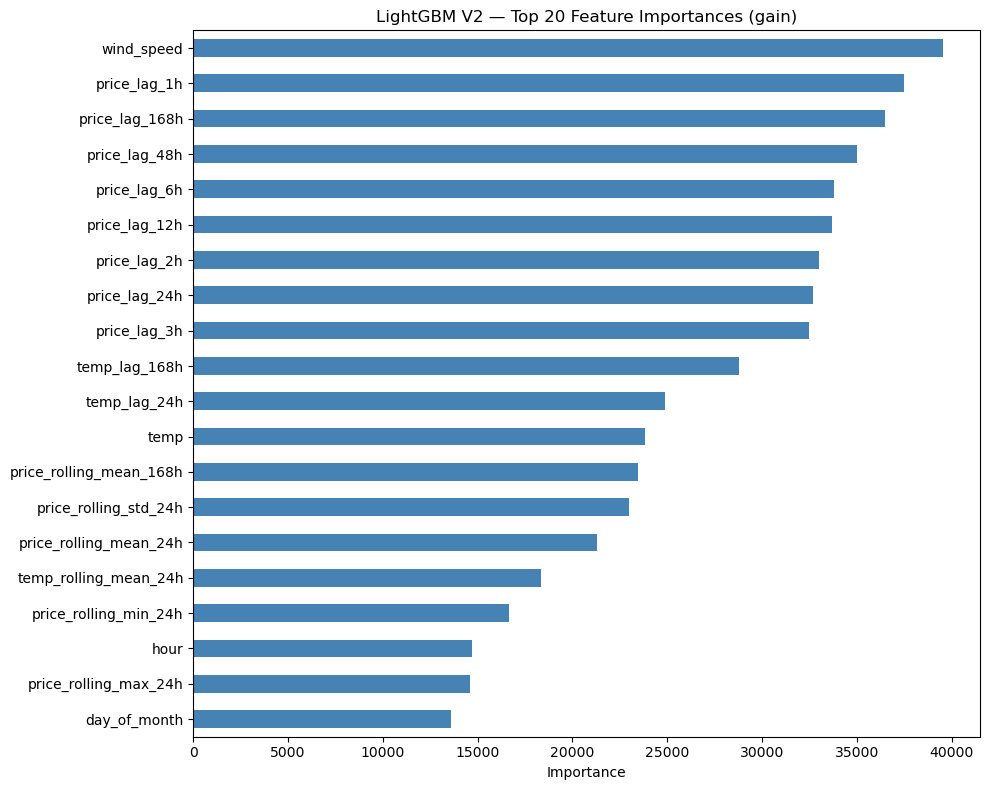

In [7]:
importance = pd.Series(
    model_v2_lgb.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

plt.figure(figsize=(10, 8))
importance.head(20).sort_values().plot(kind='barh', color='steelblue')
plt.title('LightGBM V2 — Top 20 Feature Importances (gain)')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()

## 6. Actual vs Predicted (Test Set — First 7 Days)

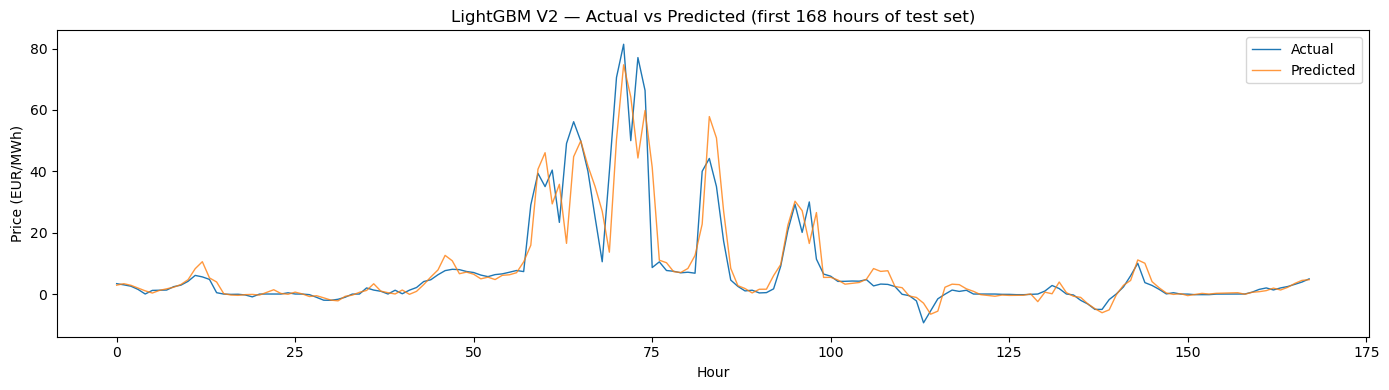

In [8]:
plt.figure(figsize=(14, 4))
plt.plot(y_test.values[:168], label='Actual', linewidth=1)
plt.plot(y_pred[:168], label='Predicted', linewidth=1, alpha=0.8)
plt.title('LightGBM V2 — Actual vs Predicted (first 168 hours of test set)')
plt.xlabel('Hour')
plt.ylabel('Price (EUR/MWh)')
plt.legend()
plt.tight_layout()
plt.show()

# Model V2 Performance Report — LightGBM

## Executive Summary

This model predicts Finland hourly electricity spot prices using 41 engineered features and LightGBM trained with a MAE objective. It achieves an average prediction error of **7.10 EUR/MWh** on the held-out test set (Jan–Dec 2025), explaining 91.1% of price variance.

---

## Results

| Metric | Value |
|--------|-------|
| MAE | 7.1017 EUR/MWh |
| MSE | 214.68 |
| RMSE | 14.6520 EUR/MWh |
| R² | 0.9107 |
| Adjusted R² | 0.9100 |
| Trees used | 5000 |

---

## What the numbers mean

An R² of 0.91 means the model explains 91% of price variance. The remaining 9% is largely genuine market shocks — grid events, geopolitical surprises, sudden generation outages — that no feature set can anticipate from historical patterns alone.

The gap between MAE (7.10) and RMSE (14.65) — roughly 2× — signals that the model makes a small number of large errors on price spike hours. These are the cases where prices move 50–100+ EUR/MWh within a single hour with no strong signal in the preceding lags. The model handles typical hours well but is surprised by true outlier events.

In practical terms, an MAE of 7.10 EUR/MWh on a market where daily prices typically range 20–100 EUR/MWh means predictions are consistently within ~10% of the true price, which is actionable for intraday trading and dispatch decisions.

---

## Why `regression_l1`

The default LightGBM objective minimises MSE, which squares every error — meaning a 30 EUR/MWh mistake on a spike hour counts 9× more than a 10 EUR/MWh mistake on a normal hour. This pushes the model to sacrifice accuracy on typical hours in order to reduce large but rare spike errors.

Switching to `regression_l1` (MAE) treats every EUR/MWh of error equally. The result is a model that is more consistently accurate across all hours rather than one that over-corrects on outliers. This is why MAE improved over the MSE-trained version while RMSE stayed roughly the same.

---

## Why the lag features matter most

The model without engineered features (V1) achieved R² = 0.107 using only raw weather. Adding price lags and rolling statistics was responsible for essentially the entire jump to 0.91.

Electricity prices are autoregressive — if prices were elevated an hour ago they are very likely still elevated now, and last week's same hour is a strong predictor of this week's same hour (weekly demand cycles, similar weather). Without access to past prices the model cannot learn this. The lag features (`price_lag_1h` through `price_lag_168h`) and rolling statistics give the model the temporal context it needs to be useful.

---

## Design choices

**Leaf-wise growth with `num_leaves=127`** allows trees to model complex interactions — for example between `is_peak_hour`, `is_holiday`, and `price_lag_24h` — that a depth-limited tree would miss.

**`subsample=0.8` and `colsample_bytree=0.8`** introduce randomness so trees are less correlated, which is how gradient boosting achieves generalisation.

**`reg_lambda=0.1`** is intentionally light. Heavier regularisation caused the model to stop too early and underfit. With 5000 trees at `learning_rate=0.05`, the slow learning and subsampling provide sufficient implicit regularisation.

**No early stopping** — early stopping was attempted but the monitor slice overlaps with training data (both are inside the 80% training window), so the monitor loss decreases continuously and never plateaus. Early stopping requires a truly unseen validation set to work. The decision was made to fix `n_estimators=5000` instead, which is safe given that test metrics plateau well before that point.

---

## Next steps

- Build LightGBM V2.5 using the 15-minute dataset (105K rows, 49 features) — more data and finer temporal resolution.
- Consider time-series cross-validation to verify performance stability across different seasons and market regimes.

In [9]:

# ── Save Model ─────────────────────────────────────────────────────────────────
import joblib
from pathlib import Path

save_dir = Path('../models/saved')
save_dir.mkdir(exist_ok=True)

joblib.dump({
    'model': model_v2_lgb,
    'feature_cols': X_train.columns.tolist(),
    'step_min': 60,
}, save_dir / 'lightgbm_v2.pkl')

print('Saved → models/saved/lightgbm_v2.pkl')
print('Feature cols:', X_train.columns.tolist())


Saved → models/saved/lightgbm_v2.pkl
Feature cols: ['temp', 'wind_speed', 'hour', 'day_of_week', 'day_of_month', 'month', 'week_of_year', 'quarter', 'year', 'season', 'is_weekend', 'is_peak_hour', 'is_night_hour', 'hour_sin', 'hour_cos', 'day_of_week_sin', 'day_of_week_cos', 'month_sin', 'month_cos', 'week_of_year_sin', 'week_of_year_cos', 'is_holiday', 'is_non_working', 'price_lag_1h', 'price_lag_2h', 'price_lag_3h', 'price_lag_6h', 'price_lag_12h', 'price_lag_24h', 'price_lag_48h', 'price_lag_168h', 'price_rolling_mean_24h', 'price_rolling_std_24h', 'price_rolling_min_24h', 'price_rolling_max_24h', 'price_rolling_mean_168h', 'temp_rolling_mean_24h', 'HDD', 'wind_power_proxy', 'temp_lag_24h', 'temp_lag_168h']
